# 2.3. Perform nested regression with bootstrapping of metric value against magnitude of ablation and biological covariate confluence

Assesses how each metrics is able to capture the variation in ablation magnitude while
being unbiased across biological covariates.

In [1]:
import pathlib
import yaml
import ast

import pandas as pd
import pyarrow.parquet as pq

from image_ablation_analysis.indexing import ParquetIndex
from image_ablation_analysis.regression.nested_regression import (
    bootstrap_nested_regression,
    BootstrapConfig,
    ColumnSpec,
)
from image_ablation_analysis.regression.visualization import plot_partial_r2_vs_r2

## Pathing

In [2]:
module_config_path = pathlib.Path("..") / '2.metrics_ablation_analysis' / 'config.yml'
if not module_config_path.exists():
    raise FileNotFoundError(f"Module config file not found: {module_config_path}")
config = yaml.safe_load(module_config_path.read_text())

abl_root = pathlib.Path(config['ablation_output_path']).resolve(strict=True)

metrics_dir = abl_root / "results" / "metrics"
if not metrics_dir.exists():
    raise FileNotFoundError(f"Metrics directory not found: {metrics_dir}")

## Read in the raw metric evaluation result
Has the metric name, metric value plus filepaths to the pair of ablated images and its raw reference

In [3]:
dataset = pq.ParquetDataset(str(metrics_dir))

table = dataset.read()
df = table.to_pandas()

print(len(df))
print(df.head())

16267608
                                      variant  \
0  xform_abl_distort=(0.1,5)_8b45fe533dc58654   
1  xform_abl_distort=(0.2,5)_eabce0e6ac52da0e   
2  xform_abl_distort=(0.4,5)_cc7c9f196649cf8a   
3  xform_abl_distort=(0.6,5)_82d5d02df8b0a3ac   
4  xform_abl_distort=(0.8,5)_0757b3cfde079b6b   

                                   original_abs_path  \
0  /mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...   
1  /mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...   
2  /mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...   
3  /mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...   
4  /mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...   

                                        aug_abs_path metric_name  metric_value  
0  /mnt/hdd20tb/alsf_ablation/SN0313537/BR0014397...         mae      0.000347  
1  /mnt/hdd20tb/alsf_ablation/SN0313537/BR0014397...         mae      0.000491  
2  /mnt/hdd20tb/alsf_ablation/SN0313537/BR0014397...         mae      0.000708  
3  /mnt/hdd20tb/alsf_ablation/SN031

In [4]:
print(df.columns)

Index(['variant', 'original_abs_path', 'aug_abs_path', 'metric_name',
       'metric_value'],
      dtype='object')


## Shared boostrap/regression parameters
All regression analysis will share the same dependent variable, whichare the metric values as well as the first (restricted) independent variable which will be the parameter value. The full independent variable and the groupings of regression analysis will change based on the confounding variable being tested for.

In [5]:
regression_config = {
    "y": "metric_value",    # dependent variable, always metric value for this analysis
    "x1": "param_values",   # independent variable 1, always the ablation parameter values for this analysis
}

bootstrap_config = {
    "n_boot": 300,
    "sample_frac": 0.5,
    "replace": True,
    "standardize": False,
    "robust_cov": None,     # or "HC3"
    "min_group_size": 25,   # prevent regression on tiny groups
}

visualization_config = {
    "hue_col": "metric_name",
    "partial_col": "partial_r2_x2",
    "r2_col": "r2_restricted",
    "partial_label": "Partial R² (confluence)",
    "r2_label": "R² Restricted (higher is better)",
}

## Read in the ablation index & some wrangling
Contains ablation magnitude and type metadata needing for regression

In [6]:
index = ParquetIndex(index_dir=abl_root / "ablated_index")
index_df = index.read()
index_df['param_values'] = index_df['param_values'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
index_df['param_values'] = index_df['param_values'].apply(lambda x: x[0] if isinstance(x, (list, tuple)) and len(x) == 1 else x)
index_df['param_swept'] = index_df['param_swept'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
index_df['param_swept'] = index_df['param_swept'].apply(lambda x: x[0] if isinstance(x, (list, tuple)) and len(x) == 1 else x)
index_df[["ablation_package", "ablation_type", "hash"]] = (
    index_df["config_id"]
    .str.split(":", n=2, expand=True, regex=False)
)
print(index_df.head())

               created_at                                run_id  \
0  20260218T201130562139Z  158233ca-0f56-414c-9c0c-1039f01abf46   
1  20260218T201130562139Z  158233ca-0f56-414c-9c0c-1039f01abf46   
2  20260218T201130562139Z  158233ca-0f56-414c-9c0c-1039f01abf46   
3  20260218T201130562139Z  158233ca-0f56-414c-9c0c-1039f01abf46   
4  20260218T201130562139Z  158233ca-0f56-414c-9c0c-1039f01abf46   

                                   original_abs_path  \
0  /mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...   
1  /mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...   
2  /mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...   
3  /mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...   
4  /mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...   

                                   original_rel_path  \
0  SN0313537/BR00143976__2024-07-04T16_04_45-Meas...   
1  SN0313537/BR00143976__2024-07-04T16_04_45-Meas...   
2  SN0313537/BR00143976__2024-07-04T16_04_45-Meas...   
3  SN0313537/BR00143976__2024-07-04T

## Merge metric eval output dataframe with ablation to produce dataframe for regression analysis

In [7]:
for_regression = pd.merge(
    index_df,
    df,
    on=["original_abs_path", "aug_abs_path", "variant"]
)
print(len(for_regression))

17042256


In [8]:
# All cell lines in plate 1 and plate 2 for the cross cell line regression analysis
for_regression_plate1 = for_regression[for_regression['platemap_file'] == 'Assay_Plate1_platemap']
print(f"Number of samples in plate1: {len(for_regression_plate1)}")

for_regression_plate2 = for_regression[for_regression['platemap_file'] == 'Assay_Plate2_platemap']
print(f"Number of samples in plate2: {len(for_regression_plate2)}")

Number of samples in plate1: 10431960
Number of samples in plate2: 6610296


## Regression Analysis 1: Plate 1 U2-OS cell line, detecting how biased each metric is against confluence

In [9]:
# Only U2-OS cell line from plate 1
for_regression_plate1_u2os = for_regression_plate1[for_regression_plate1['cell_line'] == 'U2-OS']
print(f"Number of samples in plate1 U2-OS: {len(for_regression_plate1_u2os)}")

Number of samples in plate1 U2-OS: 742896


In [10]:
colspec = ColumnSpec(
    group_cols=("metric_name", "cell_line", "ablation_type"),
    x2="seeding_density", # full regression parameters
    x2_categorical=False,
    standardize_cols=("param_values", "seeding_density"),
    **regression_config
)

cfg = BootstrapConfig(
    **bootstrap_config
)

boot_res = bootstrap_nested_regression(for_regression_plate1_u2os, colspec, cfg)

Bootstrap groups:   0%|          | 0/42 [00:00<?, ?it/s]

### Visualize

Dotted curves here indicate thresholds comparing partial r^2 to restricted r^2:
1. On red or above: confounder explains ≥100% of restricted variance (quite bad)
2. On yellow or above: confounder explains ≥50% of restricted variance (meh)
3. On green or above: confounder explains ≥10% of restricted variance (better)
4. Below green: confounder explains <10% of restricted variance

Interpretation:
If two metrics fall on the same threshold curve, generally the one to the right is better (equal bias burden but more sensitive).
If two metrics are on the same x, the one with lower y is better.
In general, the most bottom right one would be the best.  

/home/weishanli/anaconda3/envs/ablation_env/lib/python3.11/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


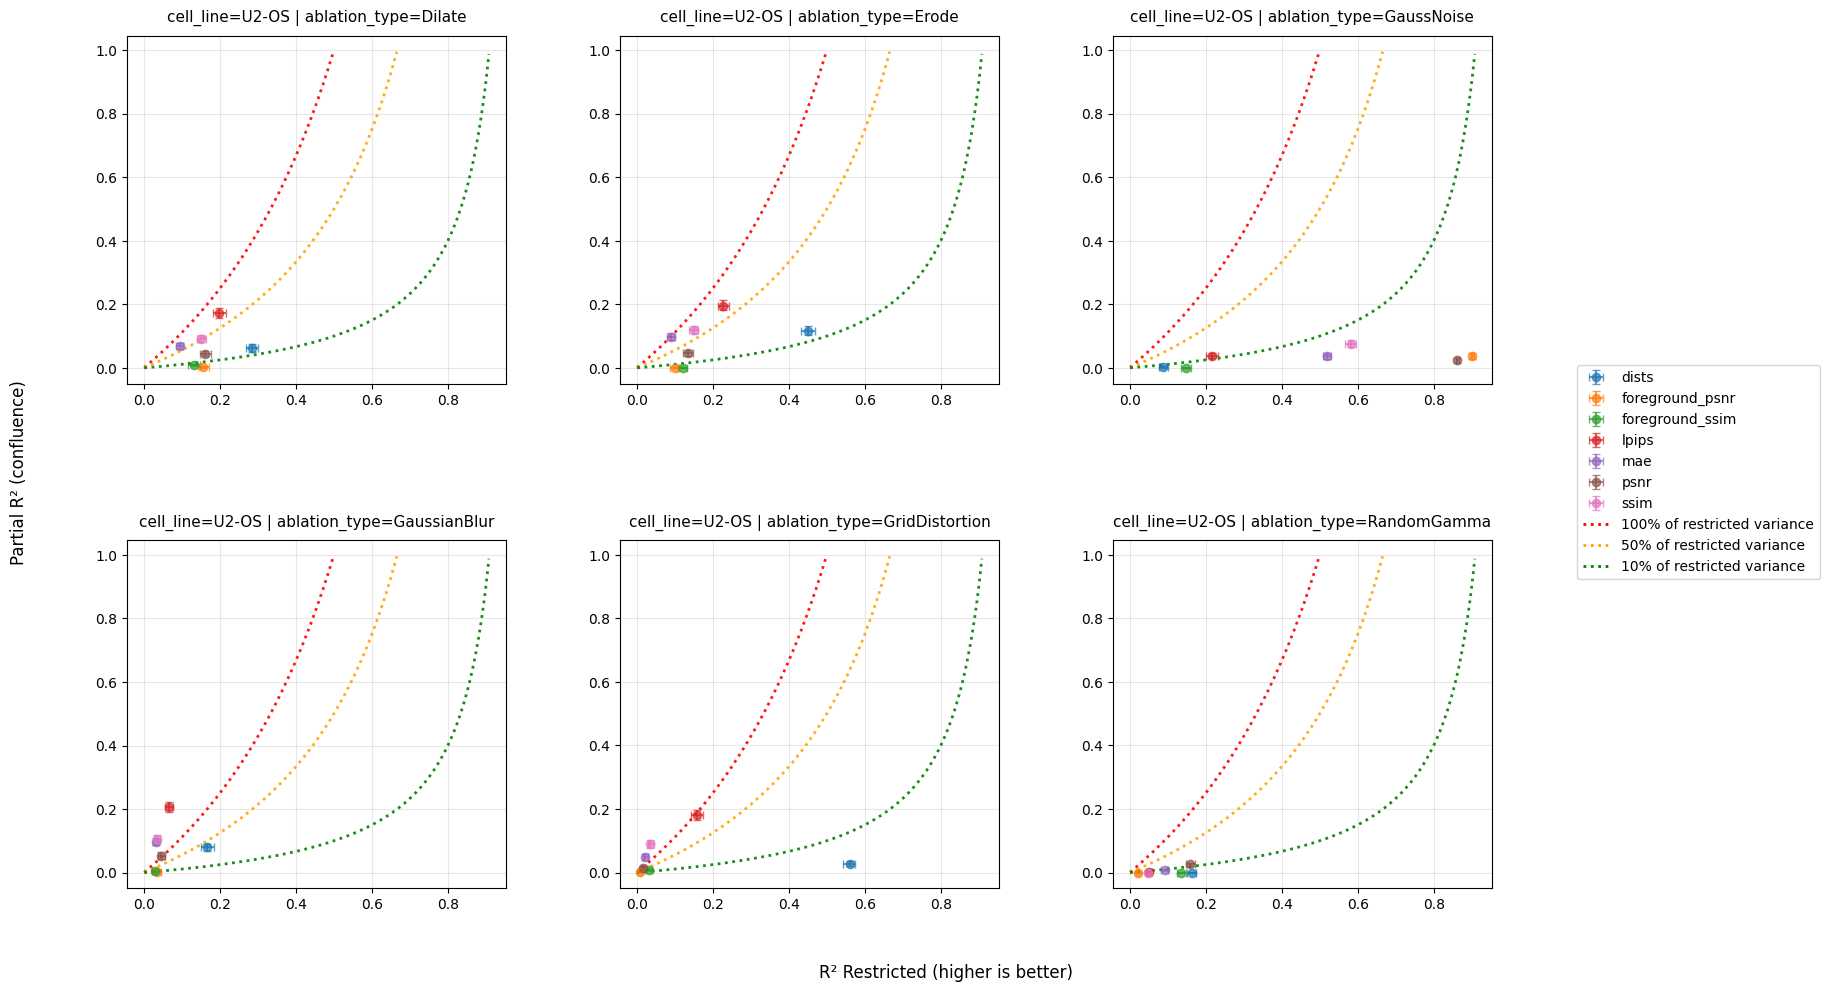

In [11]:
plot_partial_r2_vs_r2(
    boot_res=boot_res,
    panel_cols=["cell_line", "ablation_type"], 
    save_path=pathlib.Path("plots/plate1_u2os_nest_confluence.png"),
    show=True,
    **visualization_config
)

## Regression Analysis 2: Plate 2 U2-OS cell line, detecting how biased each metric is against confluence
Really just a plate 2 replicate of regression 1

In [12]:
# Only U2-OS cell line from plate 2
for_regression_plate2_u2os = for_regression_plate2[for_regression_plate2['cell_line'] == 'U2-OS']
print(f"Number of samples in plate2 U2-OS: {len(for_regression_plate2_u2os)}")

Number of samples in plate2 U2-OS: 988680


In [13]:
colspec = ColumnSpec(
    group_cols=("metric_name", "cell_line", "ablation_type"),
    x2="seeding_density", # full regression parameters
    x2_categorical=False,
    standardize_cols=("param_values", "seeding_density"),
    **regression_config
)

cfg = BootstrapConfig(
    **bootstrap_config
)

boot_res = bootstrap_nested_regression(for_regression_plate2_u2os, colspec, cfg)

Bootstrap groups:   0%|          | 0/42 [00:00<?, ?it/s]

### Visualize

/home/weishanli/anaconda3/envs/ablation_env/lib/python3.11/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


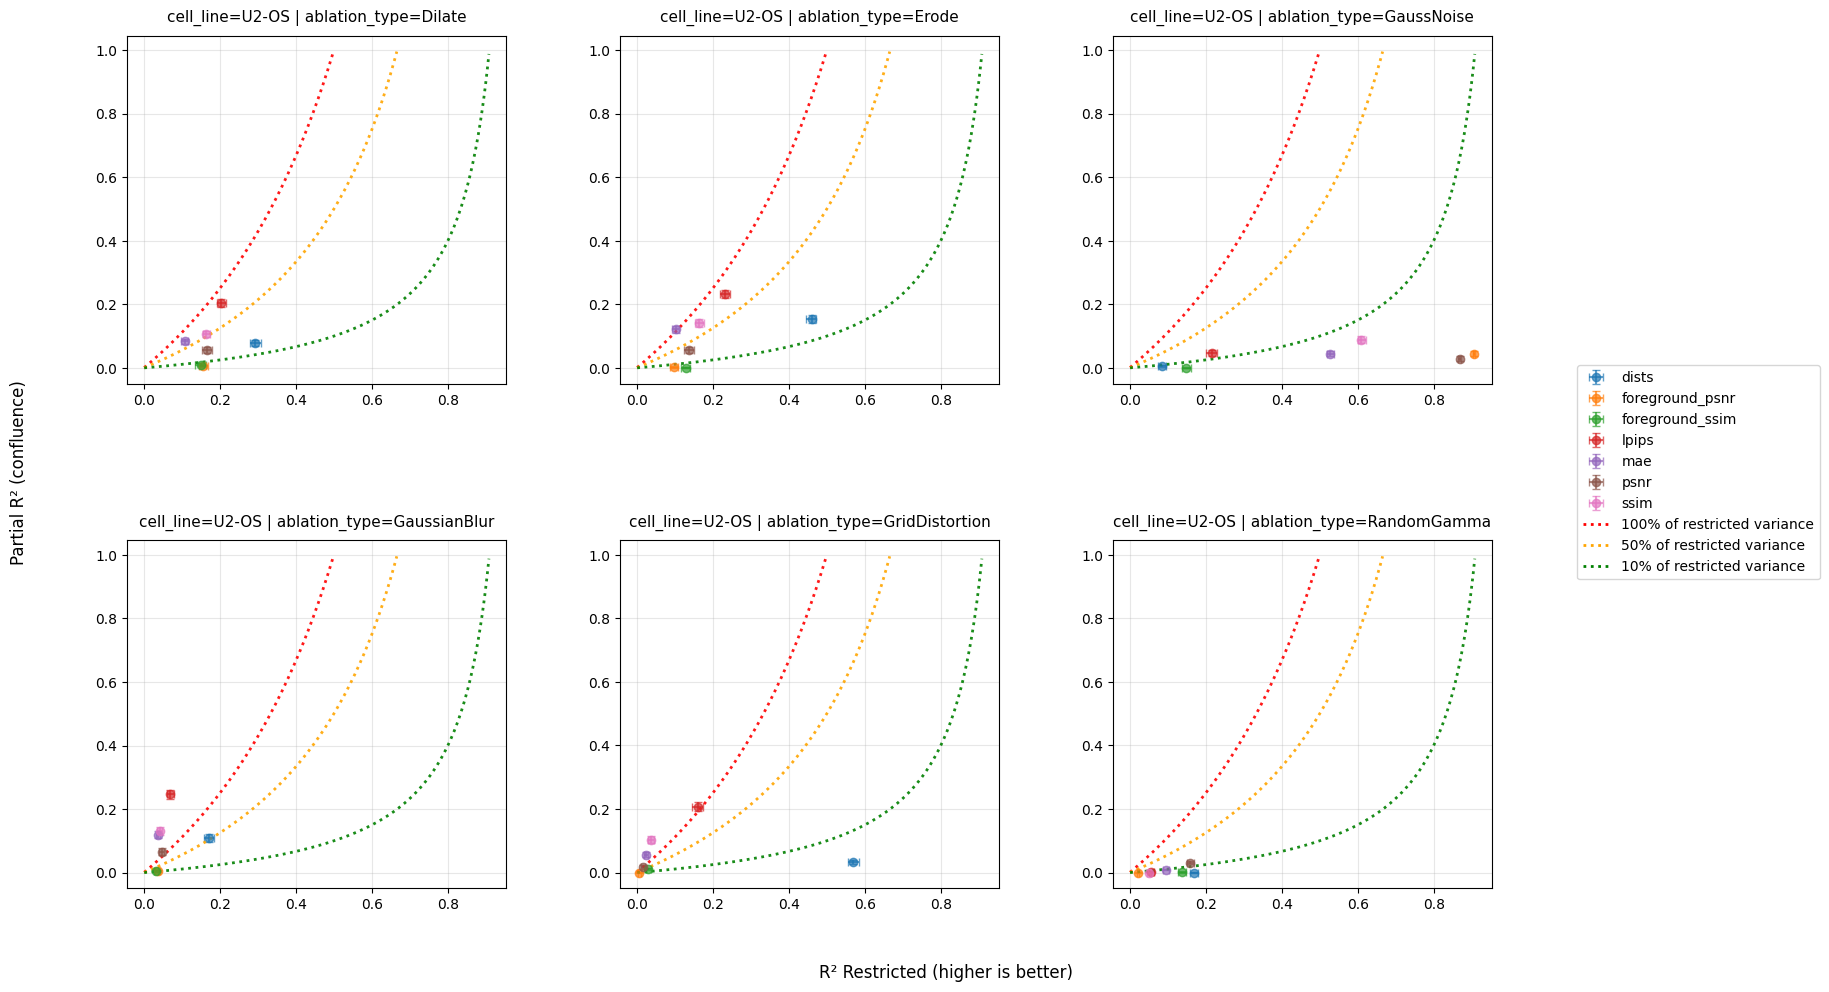

In [14]:
plot_partial_r2_vs_r2(
    boot_res=boot_res,
    panel_cols=["cell_line", "ablation_type"], 
    save_path=pathlib.Path("plots/plate2_u2os_nest_confluence.png"),
    show=True,
    **visualization_config
)

## Regression Analysis 3: Plate confluence=8000 U2-OS cell line, detecting how biased each metric is against plate

In [15]:
# U2-OS across 2 plates but only seeding density 8000 condition
for_regression_u2os_conf8000 = for_regression[
    (for_regression['cell_line'] == 'U2-OS') &
    (for_regression['seeding_density'] == 8000)
]
print(f"Number of samples in U2-OS with seeding density 8000: {len(for_regression_u2os_conf8000)}")

# Encode plate1 vs plate2
for_regression_u2os_conf8000.loc[:,'is_plate2'] = (for_regression_u2os_conf8000['platemap_file'] == 'Assay_Plate2_platemap').astype(int)
for_regression_u2os_conf8000.head()

Number of samples in U2-OS with seeding density 8000: 347424


/tmp/ipykernel_3472135/3079810872.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  for_regression_u2os_conf8000.loc[:,'is_plate2'] = (for_regression_u2os_conf8000['platemap_file'] == 'Assay_Plate2_platemap').astype(int)


,created_at,run_id,original_abs_path,original_rel_path,aug_abs_path,aug_rel_path,variant,config_id,params_json,param_fixed,...,Metadata_PositionY,Metadata_PositionZ,Metadata_Row,Metadata_Reimaged,ablation_package,ablation_type,hash,metric_name,metric_value,is_plate2
10122,20260218T201130562139Z,158233ca-0f56-414c-9c0c-1039f01abf46,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,/mnt/hdd20tb/alsf_ablation/SN0313537/BR0014397...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,"xform_abl_distort=(0.1,5)_8b45fe533dc58654",albumentations:GridDistortion:8b45fe533dc58654,"{""backend"":""albumentations"",""transform_name"":""...","[""num_steps""]",...,0.0,-0.000006,13.0,False,albumentations,GridDistortion,8b45fe533dc58654,mae,0.002564,0
10123,20260218T201130562139Z,158233ca-0f56-414c-9c0c-1039f01abf46,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,/mnt/hdd20tb/alsf_ablation/SN0313537/BR0014397...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,"xform_abl_distort=(0.1,5)_8b45fe533dc58654",albumentations:GridDistortion:8b45fe533dc58654,"{""backend"":""albumentations"",""transform_name"":""...","[""num_steps""]",...,0.0,-0.000006,13.0,False,albumentations,GridDistortion,8b45fe533dc58654,ssim,0.959869,0
10124,20260218T201130562139Z,158233ca-0f56-414c-9c0c-1039f01abf46,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,/mnt/hdd20tb/alsf_ablation/SN0313537/BR0014397...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,"xform_abl_distort=(0.1,5)_8b45fe533dc58654",albumentations:GridDistortion:8b45fe533dc58654,"{""backend"":""albumentations"",""transform_name"":""...","[""num_steps""]",...,0.0,-0.000006,13.0,False,albumentations,GridDistortion,8b45fe533dc58654,psnr,46.650364,0
10125,20260218T201130562139Z,158233ca-0f56-414c-9c0c-1039f01abf46,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,/mnt/hdd20tb/alsf_ablation/SN0313537/BR0014397...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,"xform_abl_distort=(0.1,5)_8b45fe533dc58654",albumentations:GridDistortion:8b45fe533dc58654,"{""backend"":""albumentations"",""transform_name"":""...","[""num_steps""]",...,0.0,-0.000006,13.0,False,albumentations,GridDistortion,8b45fe533dc58654,lpips,0.092429,0
10126,20260218T201130562139Z,158233ca-0f56-414c-9c0c-1039f01abf46,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,/mnt/hdd20tb/alsf_ablation/SN0313537/BR0014397...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,"xform_abl_distort=(0.1,5)_8b45fe533dc58654",albumentations:GridDistortion:8b45fe533dc58654,"{""backend"":""albumentations"",""transform_name"":""...","[""num_steps""]",...,0.0,-0.000006,13.0,False,albumentations,GridDistortion,8b45fe533dc58654,dists,0.029368,0


In [16]:
colspec = ColumnSpec(
    group_cols=("metric_name", "cell_line", "ablation_type"),
    x2="is_plate2", # full regression parameters
    x2_categorical=False,
    standardize_cols=("param_values",),
    **regression_config
)

cfg = BootstrapConfig(
    **bootstrap_config
)

boot_res = bootstrap_nested_regression(for_regression_u2os_conf8000, colspec, cfg)

Bootstrap groups:   0%|          | 0/42 [00:00<?, ?it/s]

### Visualize

/home/weishanli/anaconda3/envs/ablation_env/lib/python3.11/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


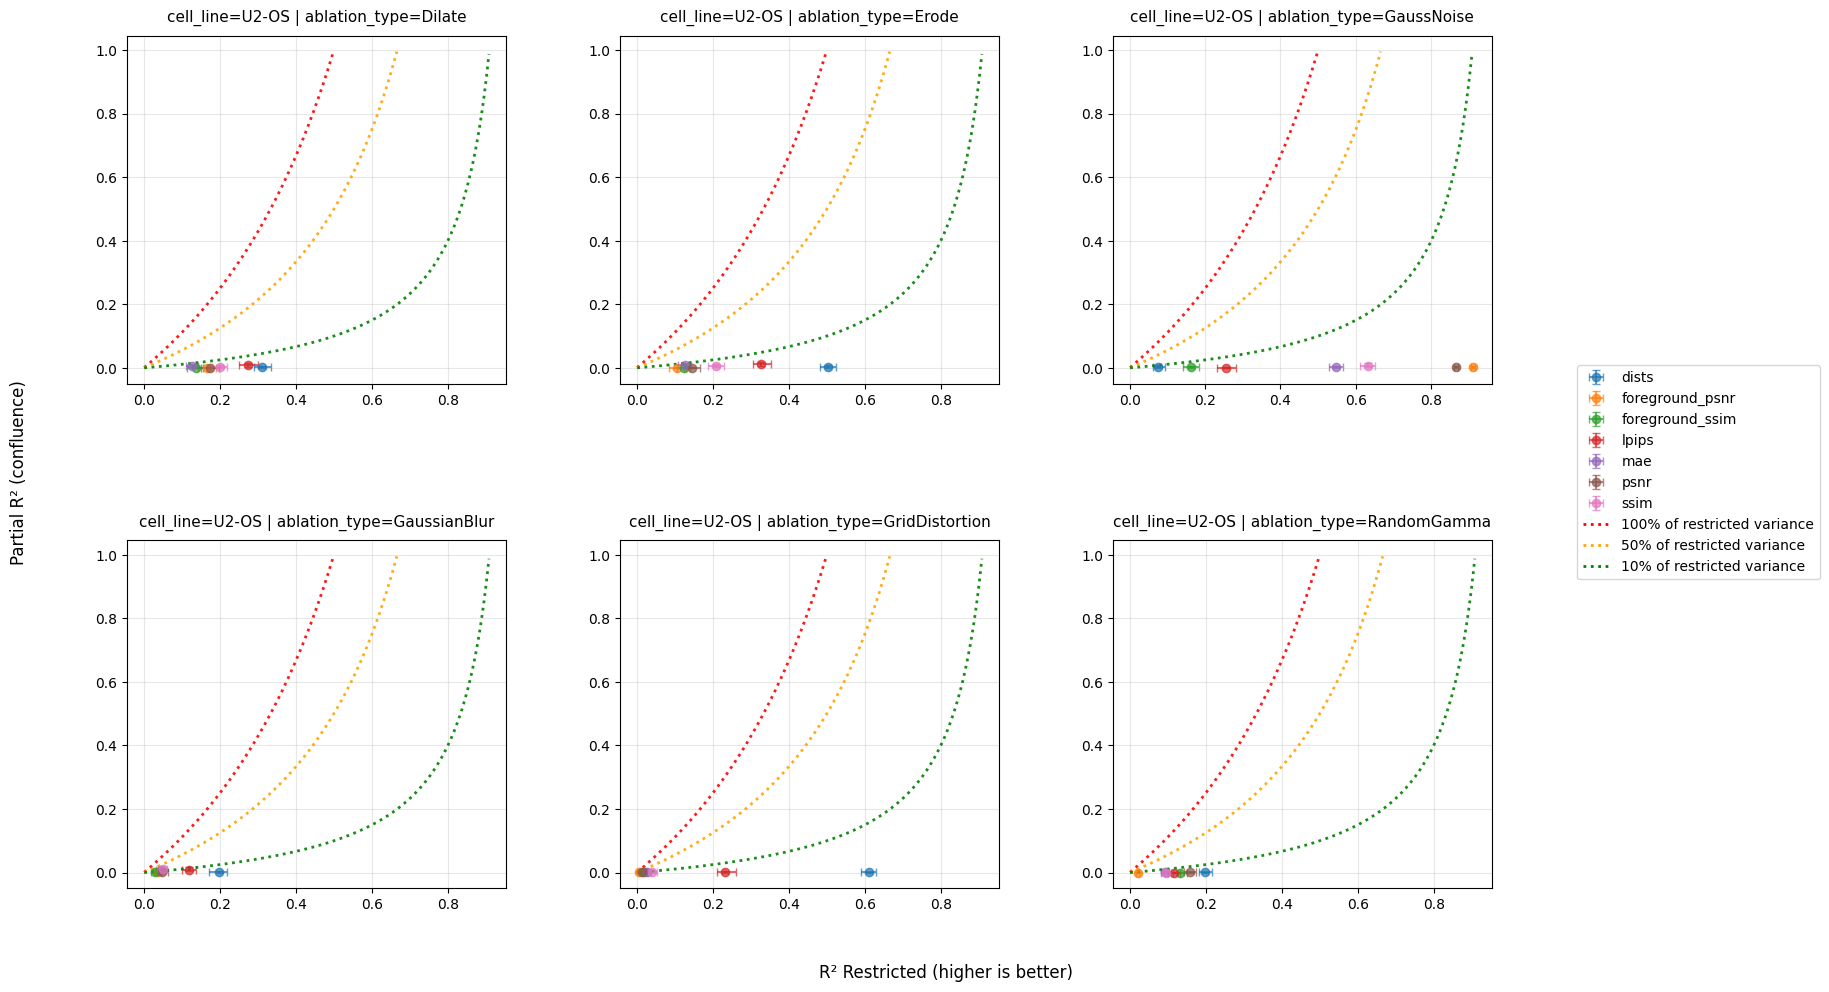

In [17]:
plot_partial_r2_vs_r2(
    boot_res=boot_res,
    panel_cols=["cell_line", "ablation_type"], 
    save_path=pathlib.Path("plots/conf8000_u2os_nest_plate.png"),
    show=True,
    **visualization_config
)

It seems like none of the metrics can pick up (and thus be biased by) any batch effect across plates!

## Regression Analysis 4: All cell lines with confluence=8000, detecting how biased each metric is against cell lines
This is a lot more samples, expect regression w/th bootstrap to take >15 minutes.

If runtime is a problem tune down `n_boot` and/or `sample_frac` in `BootstrapConfig`

In [18]:
# All cell lines in plate 1 and plate 2 for the cross cell line regression analysis
for_regression_c8000 = for_regression[
    (for_regression['seeding_density'] == 8000)
]
print(f"Number of all confluence 8000 samples: {len(for_regression_c8000)}")
for_regression_c8000.head()

Number of all confluence 8000 samples: 3270960


,created_at,run_id,original_abs_path,original_rel_path,aug_abs_path,aug_rel_path,variant,config_id,params_json,param_fixed,...,Metadata_PositionX,Metadata_PositionY,Metadata_PositionZ,Metadata_Row,Metadata_Reimaged,ablation_package,ablation_type,hash,metric_name,metric_value
10122,20260218T201130562139Z,158233ca-0f56-414c-9c0c-1039f01abf46,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,/mnt/hdd20tb/alsf_ablation/SN0313537/BR0014397...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,"xform_abl_distort=(0.1,5)_8b45fe533dc58654",albumentations:GridDistortion:8b45fe533dc58654,"{""backend"":""albumentations"",""transform_name"":""...","[""num_steps""]",...,0.0,0.0,-0.000006,13.0,False,albumentations,GridDistortion,8b45fe533dc58654,mae,0.002564
10123,20260218T201130562139Z,158233ca-0f56-414c-9c0c-1039f01abf46,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,/mnt/hdd20tb/alsf_ablation/SN0313537/BR0014397...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,"xform_abl_distort=(0.1,5)_8b45fe533dc58654",albumentations:GridDistortion:8b45fe533dc58654,"{""backend"":""albumentations"",""transform_name"":""...","[""num_steps""]",...,0.0,0.0,-0.000006,13.0,False,albumentations,GridDistortion,8b45fe533dc58654,ssim,0.959869
10124,20260218T201130562139Z,158233ca-0f56-414c-9c0c-1039f01abf46,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,/mnt/hdd20tb/alsf_ablation/SN0313537/BR0014397...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,"xform_abl_distort=(0.1,5)_8b45fe533dc58654",albumentations:GridDistortion:8b45fe533dc58654,"{""backend"":""albumentations"",""transform_name"":""...","[""num_steps""]",...,0.0,0.0,-0.000006,13.0,False,albumentations,GridDistortion,8b45fe533dc58654,psnr,46.650364
10125,20260218T201130562139Z,158233ca-0f56-414c-9c0c-1039f01abf46,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,/mnt/hdd20tb/alsf_ablation/SN0313537/BR0014397...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,"xform_abl_distort=(0.1,5)_8b45fe533dc58654",albumentations:GridDistortion:8b45fe533dc58654,"{""backend"":""albumentations"",""transform_name"":""...","[""num_steps""]",...,0.0,0.0,-0.000006,13.0,False,albumentations,GridDistortion,8b45fe533dc58654,lpips,0.092429
10126,20260218T201130562139Z,158233ca-0f56-414c-9c0c-1039f01abf46,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,/mnt/hdd20tb/alsf_ablation/SN0313537/BR0014397...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,"xform_abl_distort=(0.1,5)_8b45fe533dc58654",albumentations:GridDistortion:8b45fe533dc58654,"{""backend"":""albumentations"",""transform_name"":""...","[""num_steps""]",...,0.0,0.0,-0.000006,13.0,False,albumentations,GridDistortion,8b45fe533dc58654,dists,0.029368


In [19]:
colspec = ColumnSpec(
    group_cols=("metric_name", "platemap_file", "ablation_type"),
    x2="cell_line", # categorical var
    x2_categorical=True,
    standardize_cols=("param_values",),
    **regression_config
)

cfg = BootstrapConfig(
    **bootstrap_config
)

boot_res = bootstrap_nested_regression(for_regression_c8000, colspec, cfg)

Bootstrap groups:   0%|          | 0/84 [00:00<?, ?it/s]

### Visualize

/home/weishanli/anaconda3/envs/ablation_env/lib/python3.11/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


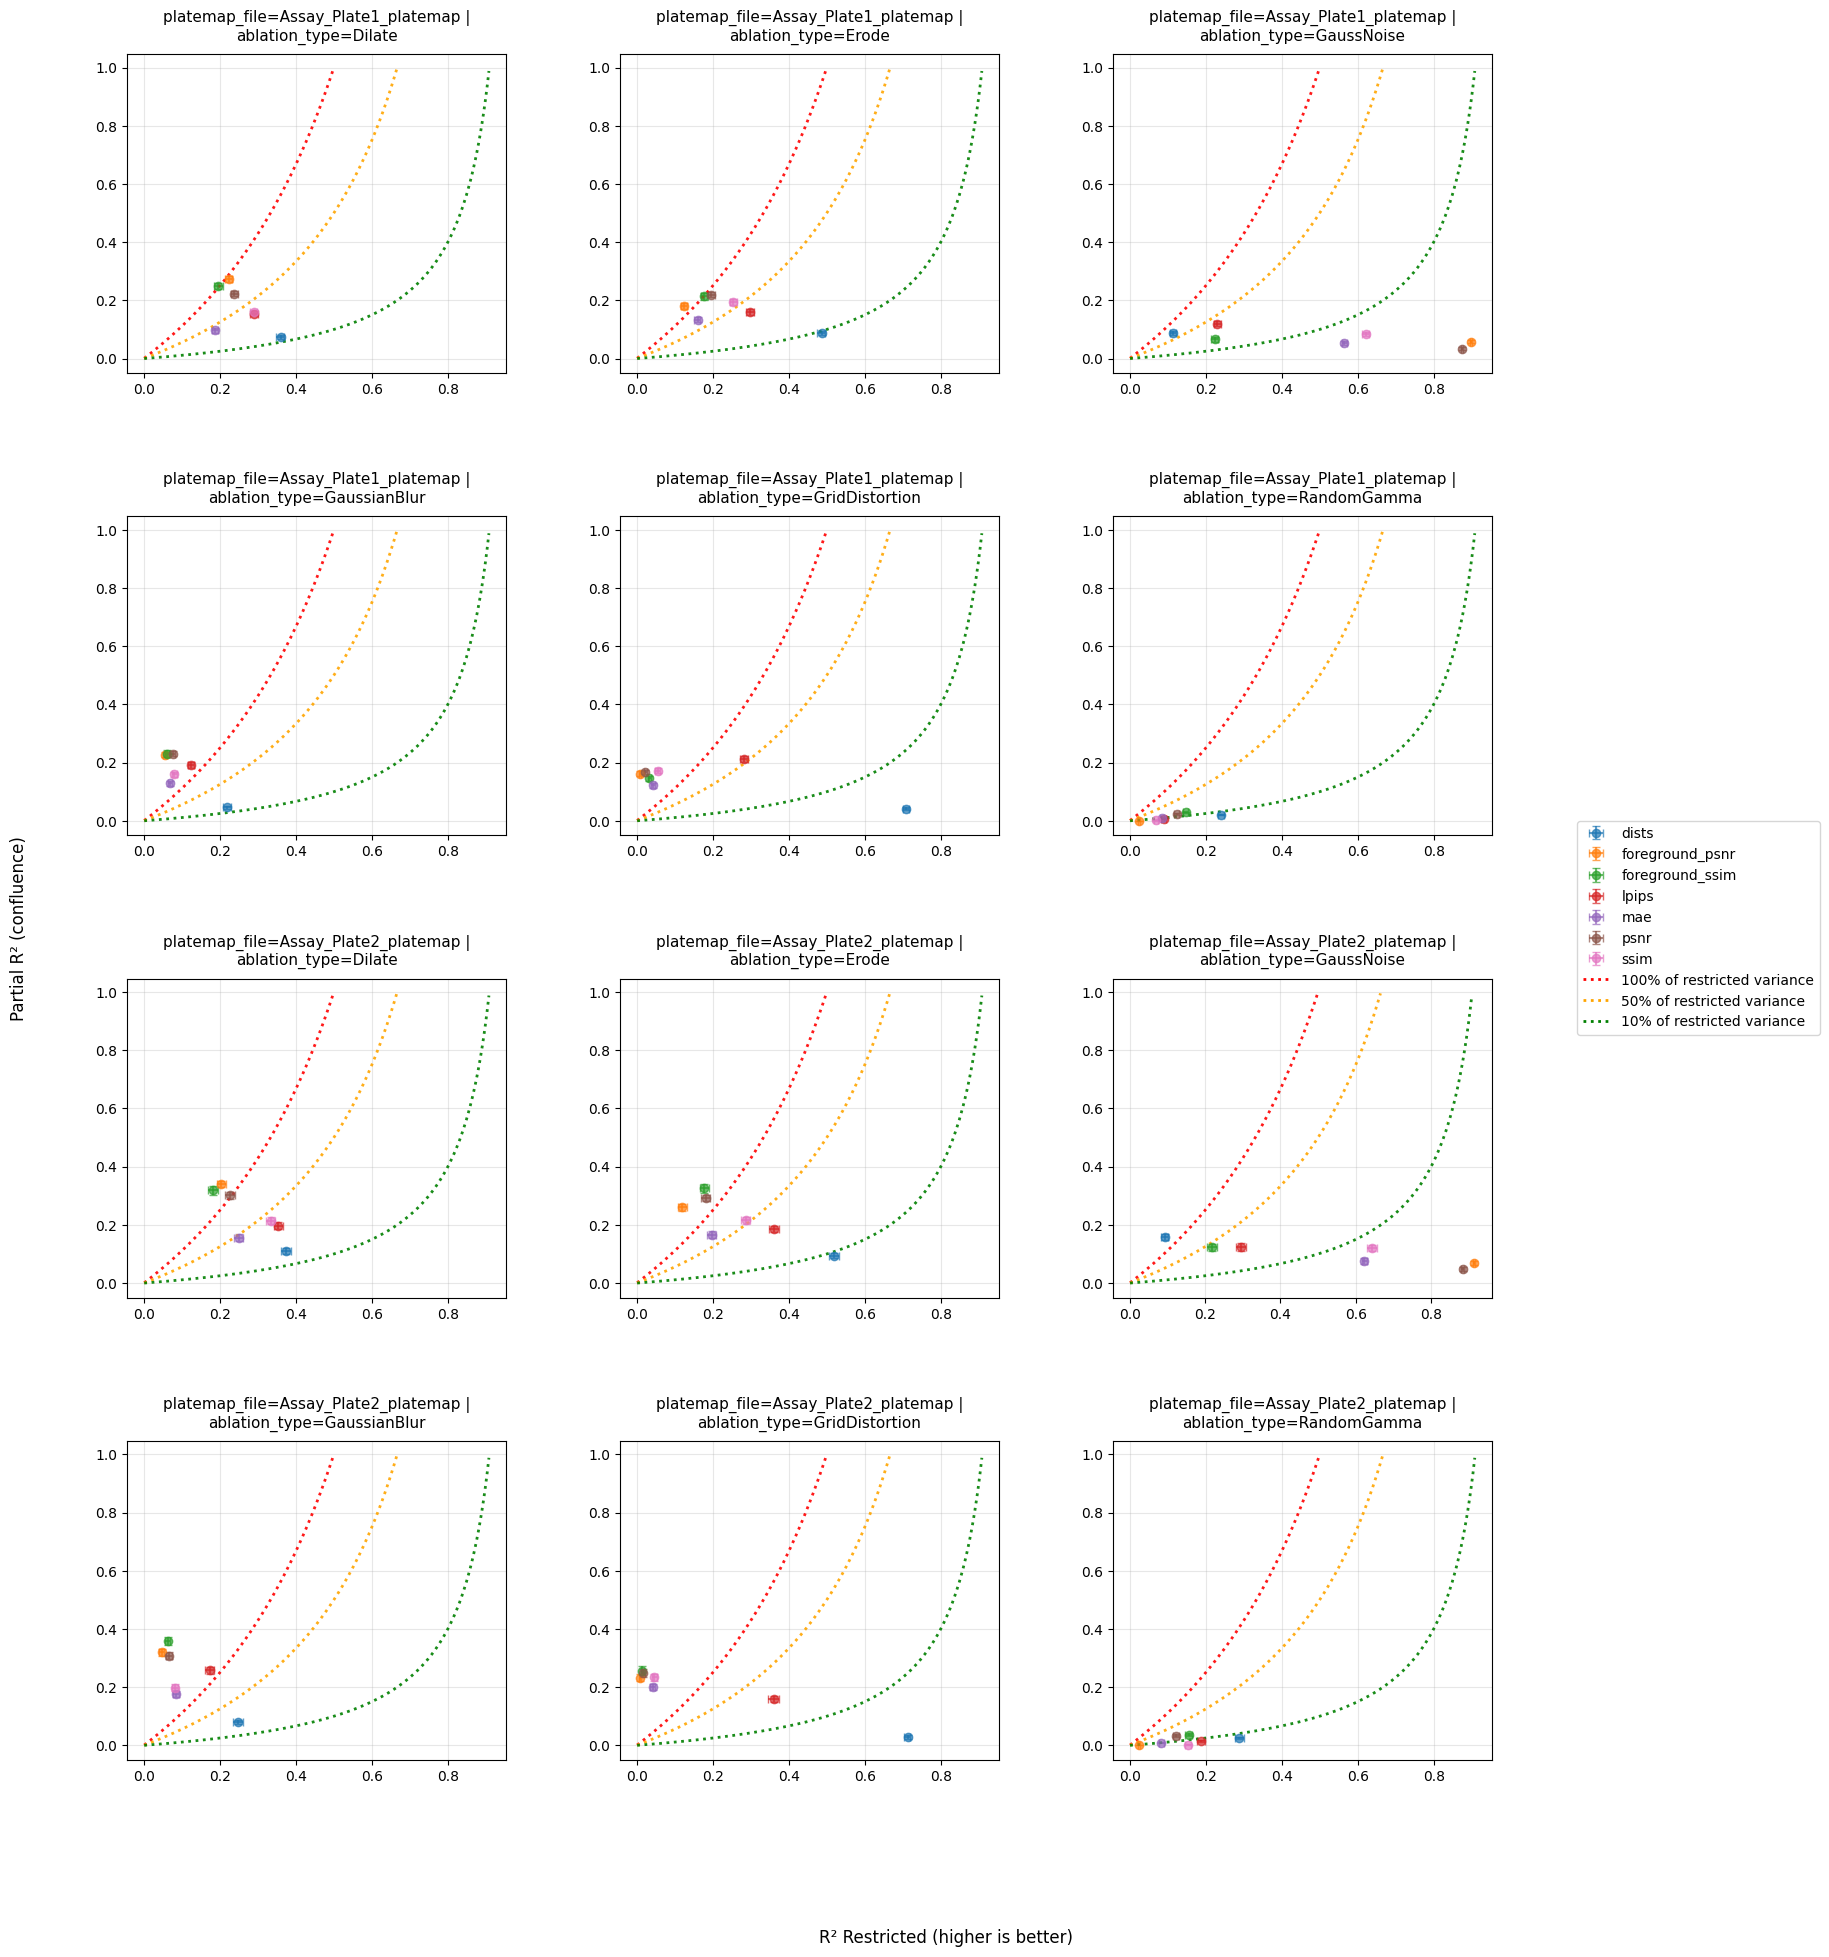

In [20]:
plot_partial_r2_vs_r2(
    boot_res=boot_res,
    panel_cols=["platemap_file", "ablation_type"],
    save_path=pathlib.Path("plots/all_conf8000_nest_cell.png"),
    show=True,
    **visualization_config
)